# Лекция: Компьютерное зрение. 
## Адаптеры в диффузионных моделях & SOTA модели. Часть 2.
**Преподаватель**: Шевченко Елена, Т-Банк

**Аудитория**: ФКН ВШЭ, МФТИ

### Содержание
1. ~~Адаптеры~~
2. ~~Recap: диифузия VS flow matching~~
3. ~~SOTA models~~
5. Model distillation  
    - Guidance distillation
    - ADD & LADD
    - Step & Progressive distillation
    - Flux1.Schnell, Flux2.Klein, Z-Image Turbo


# IV. Дистилляция диффузионных моделей
#### Проблема: хорошие модели работают медленно
Диффузионные модели генерируют изображения итеративно — шаг за шагом убирая шум. FLUX.1 [dev] требует **20–50 шагов деноизинга** для получения качественной картинки :
```
классическая диффузия:
шум → шаг 1 → шаг 2 → ... → шаг 50 → изображение
                                        ↑
                              несколько секунд на A100
                              при 12B параметрах
```
Задача дистилляции: **научить модель воспроизводить тот же результат быстрее** — либо за меньше шагов, либо за меньше вычислений на каждом шаге.
Два принципиально разных типа ускорения:
```
тип 1: меньше шагов деноизинга
→ ADD, LADD, step distillation
→ 50 шагов → 1-4 шага
→ 10-50× быстрее
тип 2: меньше forward pass на каждом шаге
→ Guidance Distillation
→ 2 прохода → 1 проход на шаг
→ 2× быстрее
```
Оба типа можно **комбинировать** — именно так устроен FLUX.1 [schnell] .

---
### 1. Guidance Distillation: убираем второй forward pass
#### Откуда берётся второй forward pass: CFG
Чтобы понять guidance distillation, нужно сначала разобраться с **Classifier-Free Guidance (CFG)** — механизмом который делает модели послушными промптам .

В классических диффузионных моделях на каждом шаге деноизинга делается **два forward pass**. На шаге $t$ вычисляются два предсказания:

$$v_\text{cond} = \text{model}(x_t,\, t,\, c)$$

$$v_\text{uncond} = \text{model}(x_t,\, t,\, \varnothing)$$

и объединяются через guidance scale $g$:

$$v_\text{cfg} = v_\text{uncond} + g \cdot (v_\text{cond} - v_\text{uncond})$$

где $g$ (например $7.5$) усиливает влияние текста на генерацию. Это даёт **2× вычислений на каждый шаг** и поддерживает negative prompts.

При 12B параметрах FLUX это **очень дорого** — каждый шаг требует двух полных проходов через всю сеть.

#### Идея Guidance Distillation
Обучить модель **имитировать результат CFG за один forward pass**, встроив guidance scale как дополнительный числовой вход :
```
классический CFG:
шаг t → forward_pass(условный)    ─┐
         forward_pass(безусловный)  ─┤→ CFG комбинирование → результат
                                     ↑
                               2 прохода
guidance distillation:
шаг t → forward_pass(условный, guidance_scale=g) → результат
                                     ↑
                               1 проход
                               guidance встроен внутрь
```

#### Процесс обучения

**Шаг 1.** Берём изображение $x_0$ и текст $c$.

**Шаг 2.** Сэмплируем timestep $t$ и шум $z$, строим зашумлённый латент:

$$x_t = (1 - t)\cdot x_0 + t \cdot z$$

**Шаг 3.** Учитель делает CFG за 2 forward pass и формирует **target для студента**:

$$v_\text{cond}   = \text{teacher}(x_t,\, t,\, c)$$

$$v_\text{uncond} = \text{teacher}(x_t,\, t,\, \varnothing)$$

$$v_\text{cfg}    = v_\text{uncond} + g \cdot (v_\text{cond} - v_\text{uncond})$$

**Шаг 4.** Студент делает 1 forward pass, принимая $g$ явным аргументом:

$$v_\text{student} = \text{student}(x_t,\, t,\, c,\, g)$$

**Шаг 5.** Лосс — студент учится воспроизводить CFG-результат учителя за один проход:

$$\mathcal{L} = \lVert v_\text{student} - v_\text{cfg} \rVert^2$$

#### Архитектурное изменение: guidance embedding
Единственное изменение в архитектуре — добавляется **guidance embedding** :
```python
# без guidance distillation:
vec = time_embedding(t)
# с guidance distillation:
vec = time_embedding(t) + guidance_embedding(g)
                                ↑
                    g кодируется тем же
                    sinusoidal embedding что и timestep
                    и суммируется с ним
```
Остальная архитектура не меняется. Модель обучается на разных значениях $g$:

| $g$ | поведение |
|-----|-----------|
| $1.0$ | не усиливай промпт |
| $3.5$ | умеренно следуй промпту ← default во FLUX [dev] |
| $7.0$ | строго следуй промпту |

#### Результат во FLUX.1/2 [dev]
```
FLUX.1/2 [dev]:
→ guidance_embed = True в конфиге
→ CFG Scale = 1.0 обязательно   ← отключает внешний CFG
→ Distilled Guidance = 3.5      ← передаётся внутрь модели
→ один forward pass на шаг
→ вдвое быстрее чем с классическим CFG
→ negative prompts не работают
  (нет безусловного прохода)
```

---


### 2. ADD: Adversarial Diffusion Distillation

![add](assets/add.jpg)

ADD — метод от Stability AI (2023), первый практический подход к **сокращению числа шагов** . Смотрим на него на примере SDXL-Turbo, потому что именно там метод был впервые применён.

#### Идея: взять лучшее от GAN и от диффузии

```
GANs:
→ быстро (один шаг)
→ но плохо масштабируются
→ mode collapse

Диффузионные модели:
→ высокое качество
→ хорошо масштабируются
→ но медленно (50+ шагов)

ADD = диффузия + adversarial training
→ скорость GAN + качество диффузии
```

#### Архитектура ADD

Три компонента в процессе обучения :

```
                    реальные данные
                          │
          ┌───────────────┼───────────────┐
          │               │               │
     учитель           студент      дискриминатор
  (frozen SDXL)      (SDXL-init)    (DINOv2-based)
          │               │               │
          │         генерирует за     отличает реал
          │          1-4 шага         от сгенерир.
          │               │               │
          └──distillation─┤               │
                    loss  │◄──adversarial─┘
                                loss
```

**Двухкомпонентный лосс:**

$$\mathcal{L} = \mathcal{L}_{\text{adv}} + \lambda \cdot \mathcal{L}_{\text{distill}}$$

- **Adversarial loss** ($\mathcal{L}_{\text{adv}}$): студент учится генерировать картинки неотличимые от реальных
- **Distillation loss** ($\mathcal{L}_{\text{distill}}$): студент учится воспроизводить генерацию учителя 

Важное замечание: adversarial loss делает модель **не чисто диффузионной** — это GAN, инициализированный диффузией .

#### Ограничения ADD

```
проблема 1: дискриминатор DINOv2
→ работает в пространстве RGB пикселей
→ требует дорогого декодирования на каждом шаге
→ большие затраты памяти

проблема 2: дискриминатор и учитель — разные модели
→ сложная оптимизация
→ DINOv2 заморожен, не адаптируется под задачу

проблема 3: разрешение
→ высокие разрешения работают хуже
```

---

### 3. LADD: Latent Adversarial Diffusion Distillation

LADD — следующий шаг от тех же авторов (2024), решающий ограничения ADD .

![ladd](assets/ladd.jpg)

#### Ключевое изменение 1: дискриминатор в латентном пространстве

```
ADD:
генерация → декодирование → RGB пиксели → DINOv2 дискриминатор
                 ↑
           дорого и медленно

LADD:
генерация → латентные features → дискриминатор
                 ↑
           быстро, меньше памяти
           никакого декодирования
```

#### Ключевое изменение 2: учитель и дискриминатор — одна модель

В ADD учитель и дискриминатор — два отдельных компонента. В LADD используется **один предобученный DiT**, который выполняет обе роли одновременно .

Почему это возможно: диффузионная модель в процессе обучения видит огромное количество реальных зашумлённых данных на разных уровнях шума. Это знание **зашито в промежуточных активациях** — внутренних представлениях которые модель строит для каждого входа.

Промежуточные активации (features) — это выходы промежуточных слоёв сети, не финальный результат:

```
DiT (упрощённо):

вход (латент x_t)
      ↓
attention блок 1  → активации_1  ← features слоя 1
      ↓
attention блок 2  → активации_2  ← features слоя 2
      ↓
      ...
      ↓
attention блок N  → финальный выход v (предсказание velocity)
```

Каждый слой строит своё представление данных:

```
ранние слои:  текстуры, края, локальные паттерны
средние слои: части объектов, структуры
поздние слои: семантика, глобальная структура
```

Реальные данные и сгенерированные студентом данные **дают разные активации** в предобученном DiT — именно это используется как дискриминационный сигнал.

#### Как устроен дискриминатор в LADD

Поверх каждого attention блока frozen DiT добавляется **маленькая голова дискриминатора** — небольшая сеть из 2D conv слоёв :

```
DiT учитель (frozen):

вход (x_t)
    ↓
attention блок 1 → features_1 → [голова D_1] → real/fake
    ↓
attention блок 2 → features_2 → [голова D_2] → real/fake
    ↓
attention блок k → features_k → [голова D_k] → real/fake
    ↓
    ...
    ↓
attention блок N → финальный выход v_teacher
```

Три компонента и что в них обучается:

```
DiT учитель (frozen):
→ веса НЕ меняются никогда
→ предоставляет features для дискриминатора
→ предоставляет v_teacher для distillation loss

головы дискриминатора D_k (trainable):
→ маленькие conv сети поверх frozen DiT
→ их веса ОБУЧАЮТСЯ
→ учатся отличать real features от fake features

DiT студент (trainable):
→ та же архитектура что DiT учитель
→ его веса ОБУЧАЮТСЯ
→ учится обмануть дискриминатора
  и воспроизвести v_teacher
```

#### Как считается лосс в LADD

Две компоненты лосса:

$$\mathcal{L}_{\text{LADD}} = \mathcal{L}_{\text{adv}} + \lambda \cdot \mathcal{L}_{\text{distill}}$$

**Adversarial loss** — adversarial игра между студентом и головами дискриминатора:

```
берём реальные данные x_0_real и сгенерированные x_0_fake:

x_t_real = add_noise(x_0_real, t)
x_t_fake = add_noise(x_0_fake, t)

прогоняем через frozen DiT:
F_real = DiT_features(x_t_real, t)   ← активации промежуточных слоёв
F_fake = DiT_features(x_t_fake, t)   ← активации промежуточных слоёв
```

Лосс дискриминатора (головы учатся различать):

$$\mathcal{L}_{D} = -\sum_k \mathbb{E}[\log D_k(F_{\text{real},k})] - \sum_k \mathbb{E}[\log(1 - D_k(F_{\text{fake},k}))]$$

Лосс студента (студент учится обманывать):

$$\mathcal{L}_{\text{adv}} = -\sum_k \mathbb{E}[\log D_k(F_{\text{fake},k})]$$

Итоговый adversarial loss — **сумма по всем головам**, каждая голова смотрит на свой уровень абстракции:

```
D_1: "правильные ли текстуры и края?"
D_k: "правильные ли структуры объектов?"
D_N: "правильная ли семантика?"
     ↑
богатый многоуровневый сигнал
аналогично perceptual loss, но через DiT а не VGG
```

**Distillation loss** — студент воспроизводит предсказание учителя:

```
v_teacher = DiT_teacher(x_t, t, c)   ← frozen, без градиента
v_student = DiT_student(x_t, t, c)   ← trainable, с градиентом
```

$$\mathcal{L}_{\text{distill}} = \mathbb{E}\left[\|v_{\text{student}} - v_{\text{teacher}}\|^2\right]$$

**Adversarial игра** — дискриминатор и студент обучаются поочерёдно:

```
шаг 1: обучаем головы дискриминатора
       студент frozen
       головы D_k учатся различать F_real от F_fake
       backward через L_D → обновляем только D_k

шаг 2: обучаем студента
       головы D_k frozen
       студент учится обмануть дискриминатор
       и воспроизвести v_teacher
       backward через L_LADD → обновляем только студента
```

#### Сравнение ADD и LADD

| | ADD | LADD |
|---|---|---|
| Год | 2023 | 2024 |
| Студент | UNet (SDXL) | DiT (SD3) |
| Дискриминатор | DINOv2 (отдельный, frozen) | головы поверх DiT учителя |
| Сигнал дискриминатора | RGB пиксели | features промежуточных слоёв DiT |
| Декодирование при обучении | нужно | не нужно |
| Уровни дискриминации | один (финальное изображение) | много (каждый attention блок) |
| Высокие разрешения | плохо | хорошо |



### Step Distillation: убираем большинство шагов
![step-d](assets/distillation_step.png)

Step Distillation — более простой метод чем ADD/LADD: **без дискриминатора, только прямая регрессия** .

#### Основная идея

Студент учится **за один свой шаг воспроизводить результат нескольких шагов учителя**:

```
учитель (50 шагов):
x_1.0 → шаг → x_0.98 → шаг → x_0.96 → ... → x_0.0

студент (4 шага):
x_1.0 → большой шаг → x_0.75 → большой шаг → ... → x_0.0
          ↑
каждый шаг студента ≈ несколько шагов учителя
```

#### Как считается лосс

Сначала вспомним обычный диффузионный лосс:

```
обычная модель:
берём x_0, добавляем шум → x_t
модель предсказывает velocity: v_θ(x_t, t)
лосс: ||v_θ(x_t, t) - (z - x_0)||²
```

В step distillation лосс другой — не предсказание velocity, а **попадание в конкретную точку траектории** :

```
шаг 1: сэмплируем начальную точку
       x_t ~ trajectory(x_0, t)
       t   ~ Uniform(0, 1)

шаг 2: учитель делает N маленьких шагов
       (torch.no_grad() — граф не строим)

       x_current = x_t
       for i in range(N):
           v = teacher(x_current, t_current)
           x_current = x_current - dt · v  ← Euler step
           t_current = t_current - dt

       x_target = x_current   ← TARGET, stop gradient

шаг 3: студент делает 1 большой шаг
       (строим граф вычислений)

       v_student = student(x_t, t)
       x_student = x_t - N·dt · v_student  ← большой Euler step

шаг 4: лосс

       L = ||x_student - x_target||²
               ↑               ↑
          куда попал       куда пришёл
          студент          учитель за N шагов
          (с градиентом)   (без градиента)
```

На пальцах:

```
учитель: "я знаю куда идти за N шагов —
          вот конечная точка x_target"

студент: "я учусь попадать туда же
          но за 1 большой шаг"

лосс:    "насколько далеко ты промахнулся"
```

#### Progressive Distillation: итеративное сжатие

![prog-d](assets/distillation_progressive.png)

Наивная дистилляция сразу в 4 шага даёт плохое качество — слишком большой прыжок. Решение — **прогрессивная дистилляция**: каждый раунд сжимает вдвое, после каждого раунда студент становится новым учителем :

```
раунд 1:
учитель: 50 шагов
студент: учится делать 2 шага учителя за 1
лосс:    ||x_student_25 - x_teacher_25||²
результат: модель на 25 шагах

раунд 2:
учитель: модель из раунда 1 (25 шагов)
студент: учится делать 2 шага за 1
лосс:    ||x_student_12 - x_teacher_12||²
результат: модель на 12 шагах

раунд 3: 12 → 6 шагов
раунд 4: 6  → 4 шага
```

После каждого раунда качество немного деградирует — но постепенно:

```
оригинал (50 шагов): качество 100%
25 шагов:            качество ~99%
12 шагов:            качество ~97%
6 шагов:             качество ~93%
4 шага:              качество ~88-90%
```

Прямая дистилляция 50 → 4 шага дала бы качество ~60-70% — прогрессивный подход значительно лучше.

#### Сравнение методов сокращения шагов

```
Step Distillation (Progressive):
→ прямая регрессия: MSE между точками траектории
→ нет дискриминатора
→ стабильное обучение
→ итеративный процесс (несколько раундов)
→ качество немного хуже ADD/LADD

ADD:
→ adversarial + distillation loss
→ дискриминатор в RGB пространстве (DINOv2)
→ нестабильнее, но качество лучше

LADD:
→ adversarial + distillation loss
→ дискриминатор в латентном пространстве (DiT features)
→ лучшее качество + стабильнее чем ADD
```


### FLUX.1 [schnell]: двухэтапная дистилляция

![schnell](assets/schnell.jpeg)

FLUX.1 [schnell] — наглядный пример **комбинирования обоих типов дистилляции** :

```
этап 1: guidance distillation
FLUX.1 base → FLUX.1 [dev]
→ убираем второй forward pass на шаге
→ guidance scale встроен внутрь
→ 20-50 шагов, один проход на шаг

этап 2: LADD (step distillation)
FLUX.1 [dev] → FLUX.1 [schnell]
→ убираем большинство шагов деноизинга
→ 1-4 шага вместо 20-50
→ guidance_embed = False
  guidance убирается полностью
```

Почему guidance убирается в schnell :

```
при 50 шагах:
→ guidance важен — направляет траекторию денойзинга
→ без него модель "теряет путь"

при 1-4 шагах:
→ траектории нет как таковой
→ модель прыгает почти напрямую к результату
→ guidance только мешает — вносит искажения
→ schnell просто не имеет guidance_embed слоя
```

Итоговая схема экономии вычислений:

```
FLUX.1 base (гипотетический):
2× forward pass × 50 шагов = 100 forward pass

FLUX.1 [dev] (+ guidance distillation):
1× forward pass × 50 шагов = 50 forward pass
                               ↑ 2× быстрее

FLUX.1 [schnell] (+ guidance distillation + LADD):
1× forward pass × 4 шага = 4 forward pass
                             ↑ 12× быстрее dev
                             ↑ 25× быстрее base
```

---

### FLUX.2 Klein: компактная архитектура + step distillation

![klein](assets/klein.jpg)

FLUX.2 Klein — **отдельная компактная архитектура**, спроектированная с нуля для эффективного инференса и затем дистиллированная через step distillation .

#### Два размера, два варианта каждый

```
FLUX.2 Klein 4B Distilled  ← 4 шага, production inference

FLUX.2 Klein 4B Base       ← 25-50 шагов, для обучения адаптеров

FLUX.2 Klein 9B Distilled  ← 4 шага, production inference

FLUX.2 Klein 9B Base       ← 25-50 шагов, для обучения адаптеров
```

#### Зачем нужны Base версии

При обучении LoRA напрямую на distilled модели происходит следующее:

```
проблема:
gradient updates меняют веса модели
    ↓
модель "забывает" что нужно делать за 4 шага
    ↓
дистилляция ломается непредсказуемо
    ↓
качество деградирует при длинных run-ах

решение — Base версии:
обучаем LoRA на Base (undistilled)
    ↓
Base сохраняет полный training signal
    ↓
после обучения переносим адаптер на Distilled
```

#### Архитектура: та же схема, меньше блоков

Klein использует ту же MM-DiT + parallel DiT схему что и FLUX.1/2 [dev], но с меньшим числом блоков и другим text encoder :

| | FLUX.1 [dev] | FLUX.2 [dev] | Klein 9B | Klein 4B |
|---|---|---|---|---|
| Параметры DiT | 12B | 32B | 9B | 4B |
| Double blocks | 19 | 8 | 8 | 5 |
| Single blocks | 38 | 48 | 24 | 20 |
| Text encoder | T5-XXL+CLIP | Mistral-Small-3.1 | Qwen3-8B | Qwen3-4B |
| Encoder context dim | 4096 (T5) | 15360 | 12288 | 7680 |
| VAE latent channels | 16 | 128 | 128 | 128 |
| Лицензия | Non-Commercial | Non-Commercial | Non-Commercial | Apache 2.0 |

**Как Klein становится компактнее:**

```
FLUX.2 [dev] → Klein 9B:
→ double blocks: 8 = 8       ← сохранены полностью
→ single blocks: 48 → 24     ← вдвое меньше
→ context dim:  15360 → 12288 ← меньше
→ text encoder: Mistral-24B → Qwen3-8B ← в 3× меньше

Klein 9B → Klein 4B:
→ double blocks: 8 → 5       ← меньше
→ single blocks: 24 → 20     ← меньше
→ context dim:  12288 → 7680  ← меньше
→ text encoder: Qwen3-8B → Qwen3-4B ← меньше
```

Важный паттерн: при сжатии **в первую очередь урезается single-stream часть**, double-stream сохраняется дольше — double-stream блоки несут критически важное взаимодействие между текстом и изображением .

---

### Z-Image-Turbo: альтернативная архитектура S3-DiT

![z-image](assets/z-image.png)

Z-Image-Turbo — дистиллированная версия Z-Image от Alibaba (Tongyi-MAI), конец 2025 года :

```
параметры: 6.15B
шаги:      8 NFE
скорость:  sub-second inference на H800 GPU
VRAM:      16GB (consumer GPU)
лицензия:  open source
```

**Архитектура: Scalable Single-Stream DiT (S3-DiT)**

Принципиально другой подход по сравнению с FLUX :

```
FLUX (dual-stream → single-stream):
текст ──┐
        ├── раздельная обработка → объединение
картинка┘

Z-Image-Turbo (pure single-stream S3-DiT):
текст + visual semantic tokens + image VAE tokens
        │
        └── конкатенируются сразу на входе
            → единый поток с самого начала
            → self-attention над всеми токенами равноправно
            → 30 слоёв, 6.15B параметров
```

**Дистилляция Z-Image-Turbo:**

```
Z-Image (базовая)
        ↓
few-step distillation    ← медленный multi-step процесс
                           сжат в 8 быстрых шагов
        ↓
RL (reinforcement learning) ← оптимизация photorealism
                               и multilingual поддержки
        ↓
Z-Image-Turbo
```

Важный момент для файнтюнинга: прямые gradient updates **отменяют дистилляцию** — требуются специальные подходы при обучении адаптеров .

---

### Итоговое сравнение методов

| | Guidance Distillation | ADD | LADD | Step Distillation |
|---|---|---|---|---|
| Что ускоряет | forward pass (2×→1×) | шаги (50→1-4) | шаги (50→4) | шаги (50→4-8) |
| Механизм | имитация CFG за 1 проход | adversarial + MSE distillation | adversarial по DiT features + MSE distillation | прямая регрессия точек траектории |
| Дискриминатор | нет | DINOv2 (RGB, отдельный) | головы поверх DiT (latent) | нет |
| Уровни дискриминации | — | один (RGB) | много (каждый attention блок) | — |
| Negative prompts | не работают | не работают | не работают | не работают |
| Стабильность обучения | высокая | низкая | средняя | высокая |
| Качество | как base | высокое | выше ADD | немного ниже ADD/LADD |
| Где применяется | FLUX.1/2 [dev] | SDXL-Turbo | FLUX.1 [schnell] | Klein, Z-Image-Turbo |

---

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

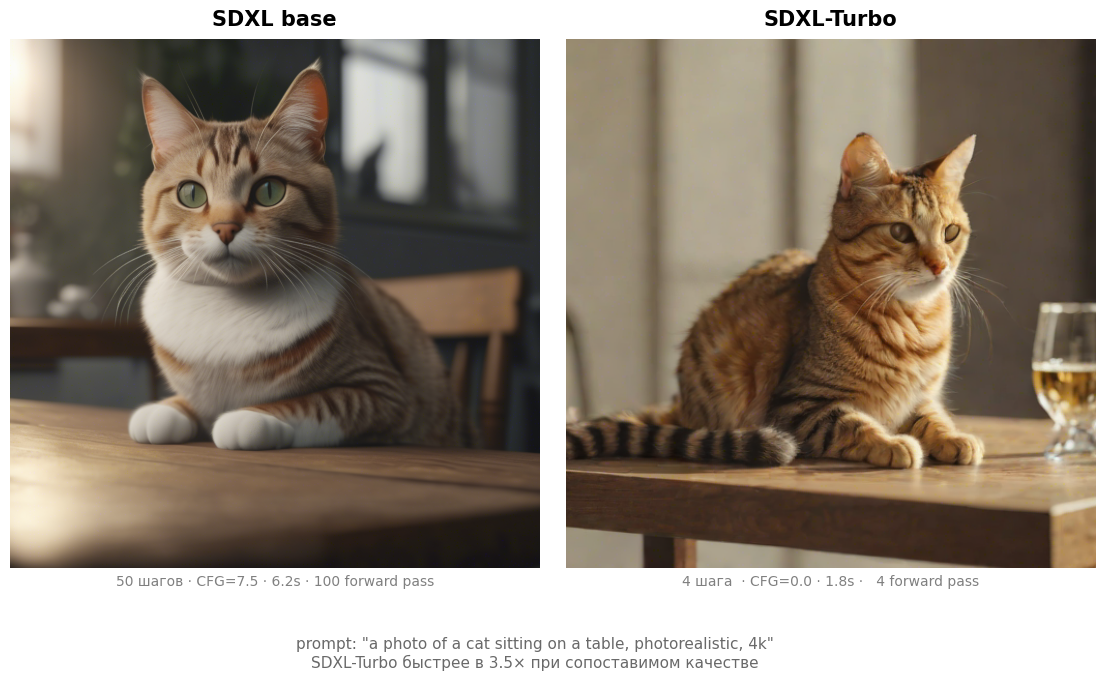

In [1]:
import torch
from diffusers import StableDiffusionXLPipeline
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

prompt = "a photo of a cat sitting on a table, photorealistic, 4k"

# --- SDXL оригинал ---
pipe_base = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
).to("cuda")

t0 = time.time()
image_base = pipe_base(
    prompt=prompt,
    num_inference_steps=50,
    guidance_scale=7.5,
).images[0]
time_base = time.time() - t0

del pipe_base
torch.cuda.empty_cache()

# --- SDXL-Turbo дистиллят ---
pipe_turbo = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16,
).to("cuda")

t0 = time.time()
image_turbo = pipe_turbo(
    prompt=prompt,
    num_inference_steps=4,
    guidance_scale=0.0,
).images[0]
time_turbo = time.time() - t0

del pipe_turbo
torch.cuda.empty_cache()

# --- визуализация ---
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2, wspace=0.05)

for idx, (img, title, subtitle) in enumerate([
    (image_base,  "SDXL base",  f"50 шагов · CFG=7.5 · {time_base:.1f}s · 100 forward pass"),
    (image_turbo, "SDXL-Turbo", f"4 шага  · CFG=0.0 · {time_turbo:.1f}s ·   4 forward pass"),
]):
    ax = fig.add_subplot(gs[idx])
    ax.imshow(img)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.set_xlabel(subtitle, fontsize=10, color="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

speedup = time_base / time_turbo
fig.suptitle(
    f'prompt: "{prompt}"\n'
    f"SDXL-Turbo быстрее в {speedup:.1f}× при сопоставимом качестве",
    fontsize=11,
    y=0.02,
    color="dimgray",
)

plt.savefig("sdxl_vs_turbo.png", dpi=150, bbox_inches="tight")
plt.show()